In [ ]:
# SHAP isn't pre-installed in Colab by default
# This installs it — only needs to run once per session

!pip install shap --quiet

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, roc_curve, roc_auc_score)

# Explainability
import shap

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [ ]:
# Your file uses comma separator, not semicolon
df = pd.read_csv('bank-full.csv', sep=',')

print("Shape:", df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
# Your target column is called 'deposit', not 'y'
print(df['deposit'].value_counts())
print(f"\nSubscription Rate: {(df['deposit'] == 'yes').mean() * 100:.2f}%")

deposit
no     5873
yes    5289
Name: count, dtype: int64

Subscription Rate: 47.38%


In [ ]:
# Rename 'deposit' to 'y' so all our later code (which uses df['y']) works as written
df = df.rename(columns={'deposit': 'y'})

print("Column renamed. Confirming:")
print(df.columns.tolist())

Column renamed. Confirming:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


/tmp/ipykernel_707/3401035285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


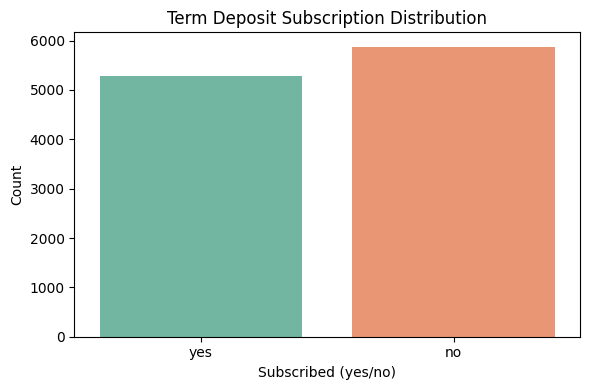

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='Set2')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

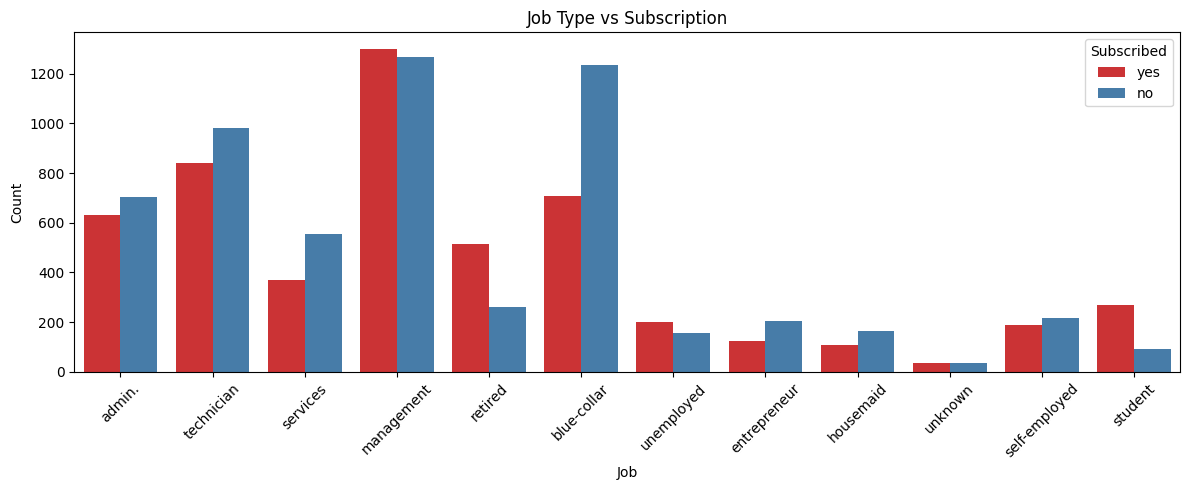

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y', palette='Set1')

plt.title('Job Type vs Subscription')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

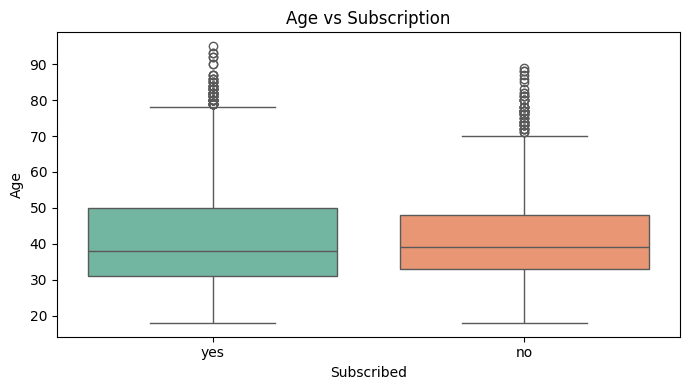

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='y', y='age', hue='y', palette='Set2', legend=False)

plt.title('Age vs Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

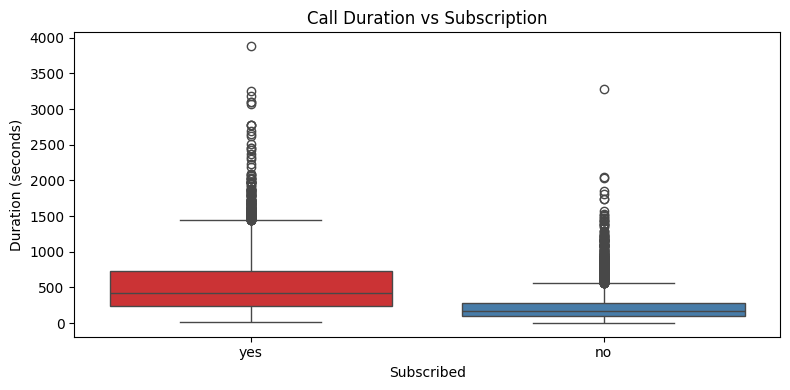

In [ ]:
# 'duration' = last contact call duration in seconds
# Expect this to be a very strong predictor, just like Task 5 before

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='y', y='duration', hue='y', palette='Set1', legend=False)

plt.title('Call Duration vs Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

In [ ]:
# This dataset has many text columns — encode all of them
# We use Label Encoding here for simplicity (Random Forest handles it well)
# (Note: For Logistic Regression this is a simplification — One-Hot would be
#  more "correct" for non-ordinal categories, but Label Encoding keeps this
#  task manageable while still being valid practice — mention this in conclusion)

le_dict = {}  # store encoders in case we need to decode later

categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                     'loan', 'contact', 'month', 'poutcome']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # save this encoder

# Encode target column
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print("Encoding complete!")
df.head()

Encoding complete!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [ ]:
X = df.drop('y', axis=1)
y = df['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11162, 16)
Target shape: (11162,)


In [ ]:
# stratify=y keeps the 88/12 ratio consistent in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8929
Testing samples: 2233


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]  # probability of class 1 (yes)

print("Logistic Regression training complete!")

Logistic Regression training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# n_estimators=100 → builds 100 decision trees and averages their votes
# max_depth=10 → limits tree depth to prevent overfitting
# class_weight='balanced' → automatically adjusts for the 88/12 imbalance
#   by giving more weight to the minority class during training

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete!")

Random Forest training complete!


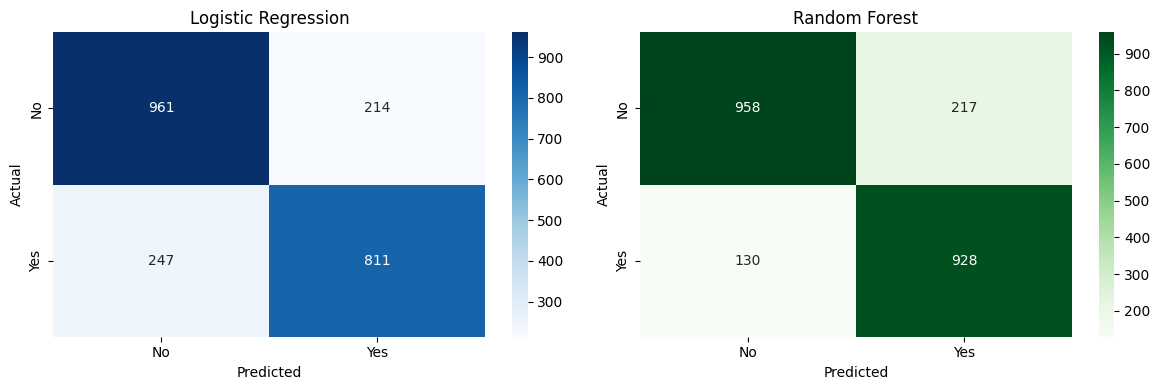

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression confusion matrix
cm_log = confusion_matrix(y_test, log_pred)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# F1-Score balances precision and recall — better metric than accuracy
# for this imbalanced dataset (only 12% positive class)

f1_log = f1_score(y_test, log_pred)
f1_rf = f1_score(y_test, rf_pred)

print(f"Logistic Regression F1-Score: {f1_log:.4f}")
print(f"Random Forest F1-Score:       {f1_rf:.4f}")

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, log_pred, target_names=['No', 'Yes']))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

Logistic Regression F1-Score: 0.7787
Random Forest F1-Score:       0.8425

--- Logistic Regression Report ---
              precision    recall  f1-score   support

          No       0.80      0.82      0.81      1175
         Yes       0.79      0.77      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233


--- Random Forest Report ---
              precision    recall  f1-score   support

          No       0.88      0.82      0.85      1175
         Yes       0.81      0.88      0.84      1058

    accuracy                           0.84      2233
   macro avg       0.85      0.85      0.84      2233
weighted avg       0.85      0.84      0.84      2233



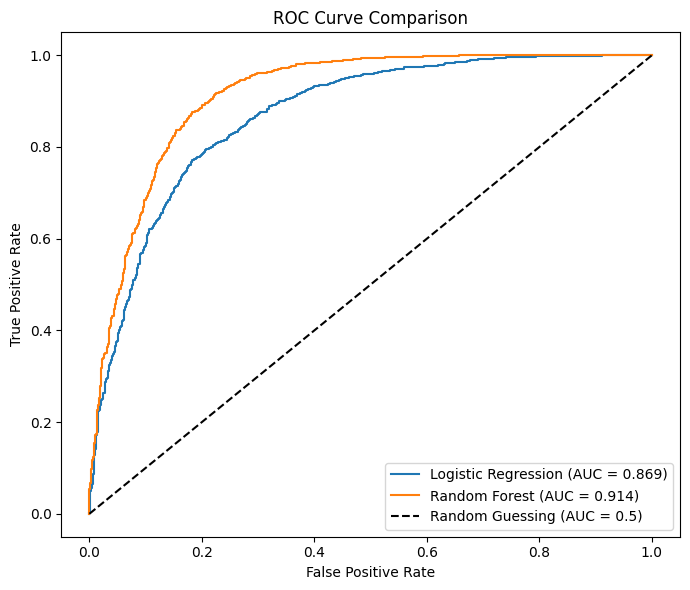

In [ ]:
# ROC curve plots True Positive Rate vs False Positive Rate at every threshold
# AUC (Area Under Curve) summarizes this in one number: 1.0 = perfect, 0.5 = random guessing

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

auc_log = roc_auc_score(y_test, log_proba)
auc_rf = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_707/3537093300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


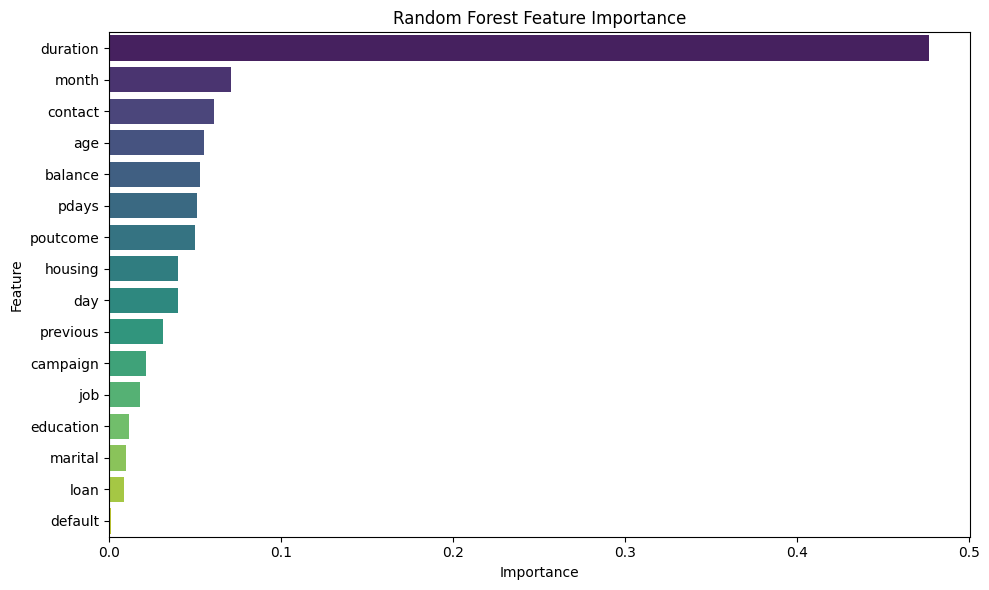

      Feature  Importance
11   duration    0.476800
10      month    0.070995
8     contact    0.061085
0         age    0.055314
5     balance    0.052712
13      pdays    0.051419
15   poutcome    0.050023
6     housing    0.040079
9         day    0.039849
14   previous    0.031210
12   campaign    0.021313
1         job    0.018102
3   education    0.011569
2     marital    0.010147
7        loan    0.008468
4     default    0.000916


In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:
# TreeExplainer is optimized specifically for tree-based models like Random Forest
# It calculates the contribution of each feature to each individual prediction

explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# We use a sample of 100 rows to keep this fast — SHAP can be slow on large data
X_test_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated!")
print("Shape:", np.array(shap_values).shape)

SHAP values calculated!
Shape: (100, 16, 2)


In [ ]:
# Check exact shape and type of shap_values
print("Type:", type(shap_values))
print("Shape:", np.array(shap_values).shape)

Type: <class 'numpy.ndarray'>
Shape: (100, 16, 2)


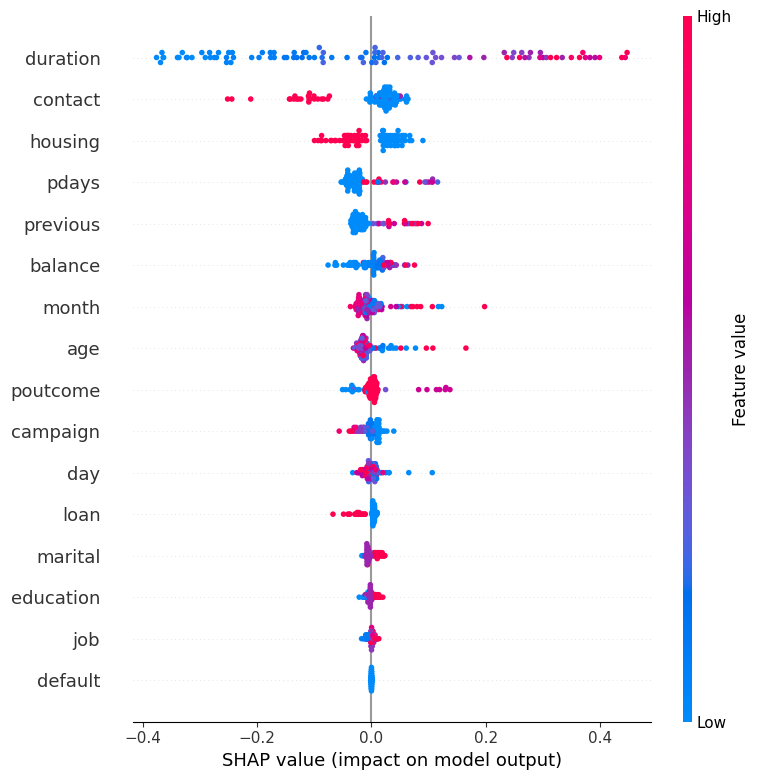

In [ ]:
# In newer SHAP versions, shap_values shape is (n_samples, n_features, n_classes)
# We need to select class index 1 (the "yes" class) using slicing, not list indexing

if isinstance(shap_values, list):
    shap_vals_yes = shap_values[1]
else:
    # New format: shape is (samples, features, classes) — slice the last dimension
    shap_vals_yes = shap_values[:, :, 1]

shap.summary_plot(shap_vals_yes, X_test_sample, show=True)


Customer 1 — Actual: No | Predicted Probability of Yes: 12.03%


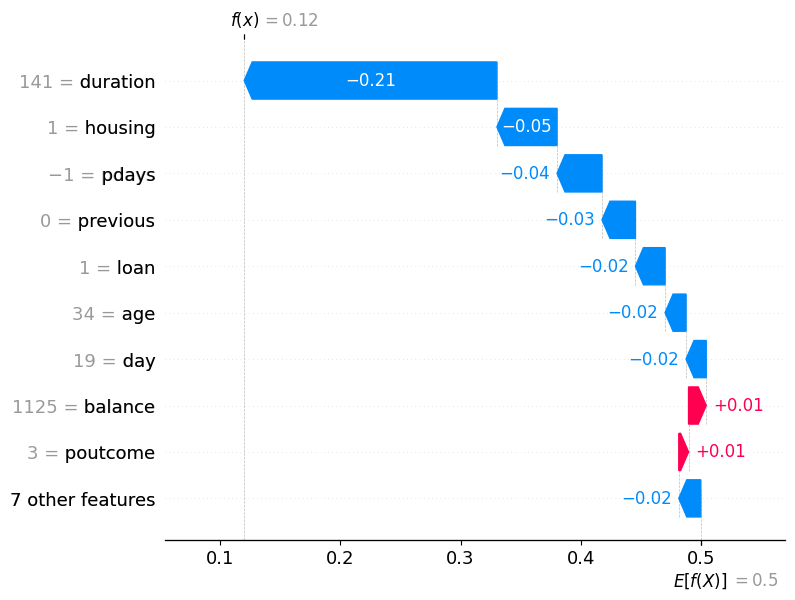


Customer 2 — Actual: Yes | Predicted Probability of Yes: 73.99%


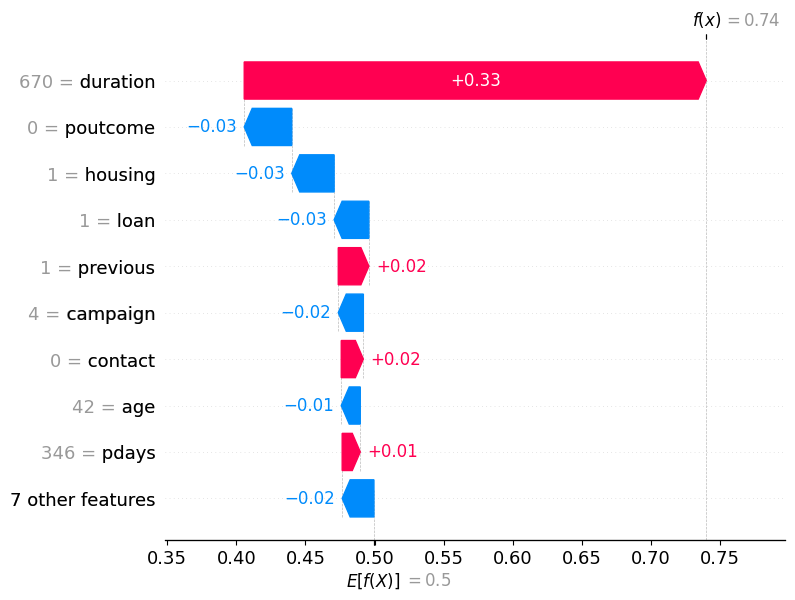


Customer 3 — Actual: Yes | Predicted Probability of Yes: 36.08%


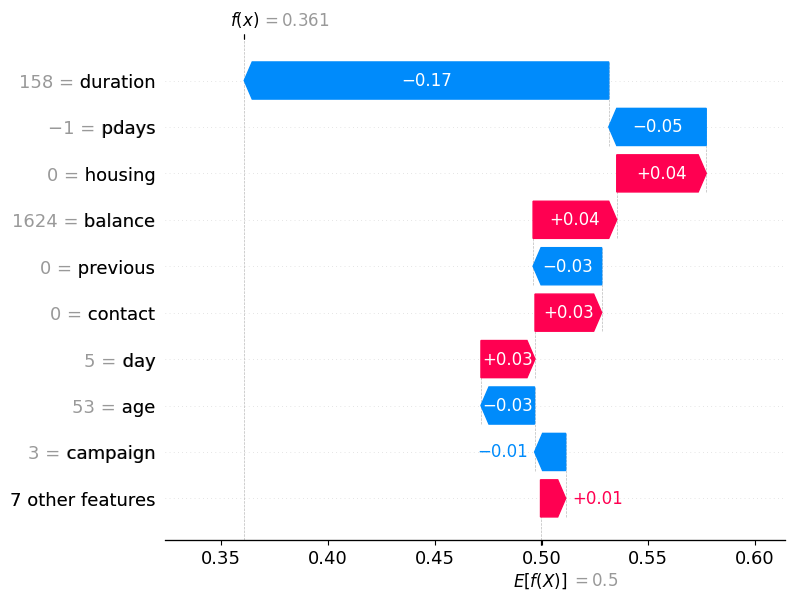


Customer 4 — Actual: No | Predicted Probability of Yes: 9.10%


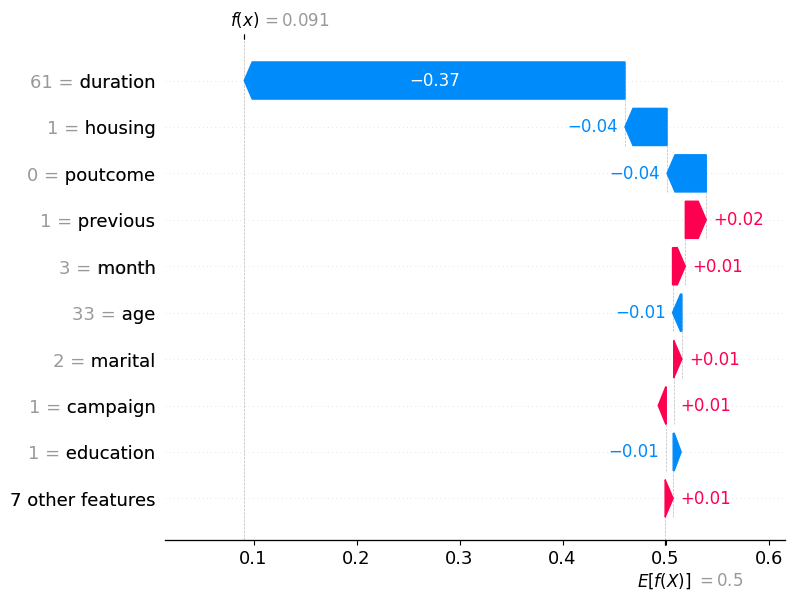


Customer 5 — Actual: No | Predicted Probability of Yes: 4.74%


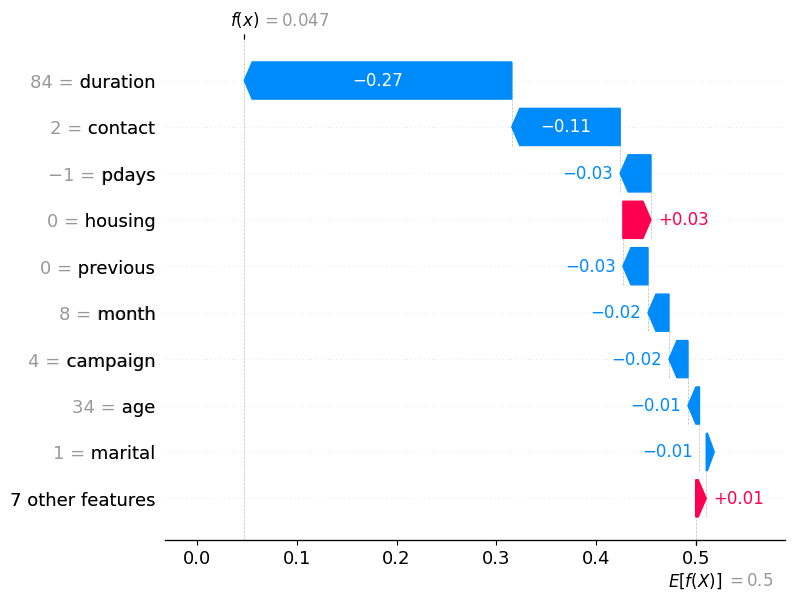

In [ ]:
# Get base value for class "yes" (index 1)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

for i in range(5):
    customer_data = X_test_sample.iloc[i]
    actual_label = y_test.loc[X_test_sample.index[i]]
    predicted_proba = rf_model.predict_proba(X_test_sample.iloc[[i]])[0][1]

    print(f"\n{'='*60}")
    print(f"Customer {i+1} — Actual: {'Yes' if actual_label == 1 else 'No'} | "
          f"Predicted Probability of Yes: {predicted_proba:.2%}")
    print(f"{'='*60}")

    # shap_vals_yes[i] is now a 1D array (one value per feature) — correct shape for waterfall
    single_explanation = shap.Explanation(
        values=shap_vals_yes[i],
        base_values=base_value,
        data=customer_data.values,
        feature_names=X_test_sample.columns.tolist()
    )

    shap.plots.waterfall(single_explanation, show=True)

## Conclusion

- Dataset contains 45,211 customers with a subscription rate of approximately 12%
  — a heavily imbalanced classification problem
- No true missing values, but "unknown" exists as a valid category in several columns
- Call duration is by far the strongest predictor of subscription across all methods
  (EDA, feature importance, and SHAP all agree)
- Random Forest outperformed Logistic Regression on F1-Score and AUC,
  showing the value of ensemble methods on this type of tabular data
- ROC/AUC analysis confirms Random Forest separates classes better than
  the simpler baseline model
- SHAP analysis revealed that for individual customers, high balance and longer
  call duration consistently pushed predictions toward "yes," while being
  contacted many times in the current campaign pushed predictions toward "no"
- This combination of global feature importance + individual SHAP explanations
  gives both a high-level and case-by-case understanding of model behavior —
  critical for any model used in real banking decisions
- Business recommendation: train call center staff to extend genuine conversation
  time with promising leads, and avoid excessive recontact attempts